## Q6. Contribution of Top 10 Best‑Selling Games

### Why this matters
Shows whether gaming is a hit‑driven or franchise‑driven industry.

### Code
The following code extracts the top 10 best‑selling games,  
computes their combined sales, and calculates their percentage contribution  
to total global sales.

# Top 10 games by global sales
top10_games = df.sort_values("Global_Sales", ascending=False).head(10)

# Total sales of top 10
top10_total = top10_games["Global_Sales"].sum()

# Total global sales
total_global_sales = df["Global_Sales"].sum()

# Percentage contribution
top10_percentage = (top10_total / total_global_sales) * 100

top10_games, top10_total, total_global_sales, top10_percentage


## Q5. Publisher Dominance by Region

### Why this matters
Publisher success is directly tied to regional genre preferences.

### Code
The following code computes the top publishers in each region by sorting  
regional sales independently for NA, EU, JP, and Other.

# Total regional sales per publisher
publisher_region_sales = (
    df.groupby("Publisher")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]]
      .sum()
)

# Top publishers per region
top_na_publishers = publisher_region_sales.sort_values("NA_Sales", ascending=False).head(10)
top_eu_publishers = publisher_region_sales.sort_values("EU_Sales", ascending=False).head(10)
top_jp_publishers = publisher_region_sales.sort_values("JP_Sales", ascending=False).head(10)
top_other_publishers = publisher_region_sales.sort_values("Other_Sales", ascending=False).head(10)

top_na_publishers, top_eu_publishers, top_jp_publishers, top_other_publishers



## Q4. Genre Preferences by Region

### Why this matters
Regional tastes explain why certain publishers succeed in specific markets.

### Code
The following code groups sales by genre and sums regional sales to reveal  
which genres dominate in NA, EU, JP, and Other regions.

# Total regional sales per genre
region_genre_sales = (
    df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]]
      .sum()
      .sort_values("NA_Sales", ascending=False)
)

region_genre_sales


## Q3. Genre Popularity Over Time

### Why this matters
Genres reveal consumer preferences and how they evolve across decades.

### Code
The following code computes total global sales per genre per year, smooths the data using a rolling average,  
and plots the top 5 genres to show long‑term popularity trends.

import pandas as pd
import matplotlib.pyplot as plt

# Remove rows with missing Year
df_years = df.dropna(subset=["Year"])

# Total global sales per genre per year
genre_year_sales = (
    df_years.groupby(["Year", "Genre"])["Global_Sales"]
            .sum()
            .reset_index()
)

# Pivot into Year × Genre matrix
genre_pivot = genre_year_sales.pivot(
    index="Year",
    columns="Genre",
    values="Global_Sales"
)

# Smooth with rolling average
genre_smooth = genre_pivot.rolling(window=3, min_periods=1).mean()

# Select top 5 genres
top_genres = genre_pivot.sum().sort_values(ascending=False).head(5).index

# Plot
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(14,7))

for genre in top_genres:
    plt.plot(
        genre_smooth.index,
        genre_smooth[genre],
        label=genre,
        linewidth=2.5
    )

plt.axvline(2008, color='grey', linestyle='--', alpha=0.4)
plt.title("Genre Popularity Over Time (Smoothed Global Sales)")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Q2. Global Sales Over Time (1980–2020)

### Why this matters
Sales trends reveal platform lifecycles, industry booms, and structural transitions.

### Code
The following code groups global sales by year and plots the overall trend from 1980 to 2020.  
This visualization highlights major industry eras and the physical‑sales decline after 2010.

import matplotlib.pyplot as plt

# Group by Year and sum global sales
sales_per_year = df.groupby("Year")["Global_Sales"].sum()

# Plot
plt.figure(figsize=(12,6))
plt.plot(sales_per_year.index, sales_per_year.values, marker='o', linewidth=2)

plt.title("Global Video Game Sales Over Time (1980–2020)")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Q1. Top Publishers by Global Sales

### Why this matters
Publisher dominance reveals how concentrated the industry is and which companies drive global sales.

### Code
The following code groups sales by publisher and sums global sales across all regions.  
A sorted table highlights the top publishers in the industry.

# Total global sales per publisher
publisher_sales = (
    df.groupby("Publisher")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
)

publisher_sales.head(10)


### Interpretation

Nintendo leads by a large margin due to evergreen franchises and platform exclusivity.  
EA and Activision follow, driven by high‑volume multi‑platform releases.  
The market is highly concentrated: the top 10 publishers account for ~70% of all sales.


## Analysis Roadmap

This notebook answers six core analytical questions:

1. Who are the top publishers globally?
2. How have global sales changed over time?
3. How has genre popularity evolved?
4. How do genre preferences differ by region?
5. Which publishers dominate each region?
6. How much do the top 10 games contribute to total sales?

Each section includes:
- Clean code  
- Polished visualizations  
- Clear, concise interpretation  


## Dataset Overview

**Source:** Kaggle – Video Game Sales Dataset  
**Rows:** ~16,600  
**Columns:** 11  
**Time Span:** 1980–2020  
**Regions:** NA, EU, JP, Other  
**Sales Type:** Physical retail sales only  

### Important Limitations
- Digital sales (Steam, PSN, Xbox Live, eShop) are **not included**  
- Modern platforms (Switch, PS4 late era, PS5) are **under‑represented**  
- Post‑2015 decline reflects **dataset cutoff**, not industry collapse  

Understanding these limitations is essential for correct interpretation.


# Global Video Game Sales Analysis (1980–2020)

## Executive Summary

This project analyzes 40 years of global video game sales data to uncover trends in:
- Publisher dominance  
- Genre popularity  
- Regional preferences  
- Platform lifecycles  
- Market concentration  

The analysis demonstrates strong proficiency in:
- Data cleaning  
- Grouping & aggregation  
- Pivoting  
- Time‑series analysis  
- Visualization  
- Insight generation  

This notebook is designed as a professional, portfolio‑ready case study suitable for GitHub and job applications in data analysis.


In [53]:
# Step 12 - Top 10 Games Contribution


# Sort games by global sales
top10_games = df.sort_values("Global_Sales", ascending=False).head(10)

# Total sales of top 10 games
top10_total = top10_games["Global_Sales"].sum()

# Total global sales across all games
total_global_sales = df["Global_Sales"].sum()

# Percentage contribution
top10_percentage = (top10_total / total_global_sales) * 100

top10_games, top10_total, total_global_sales, top10_percentage


(   Rank                       Name Platform    Year         Genre Publisher  \
 0     1                 Wii Sports      Wii  2006.0        Sports  Nintendo   
 1     2          Super Mario Bros.      NES  1985.0      Platform  Nintendo   
 2     3             Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
 3     4          Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
 4     5   Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   
 5     6                     Tetris       GB  1989.0        Puzzle  Nintendo   
 6     7      New Super Mario Bros.       DS  2006.0      Platform  Nintendo   
 7     8                   Wii Play      Wii  2006.0          Misc  Nintendo   
 8     9  New Super Mario Bros. Wii      Wii  2009.0      Platform  Nintendo   
 9    10                  Duck Hunt      NES  1984.0       Shooter  Nintendo   
 
    NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
 0     41.49     29.02      3.77         8.46         82

In [52]:
# Step 11 - Publisher Dominance by Region.

# Q. Which publishers dominate NA, EU, JP, and Other regions — and how do these dominance patterns differ?


# Group by Publisher and sum regional sales
publisher_region_sales = (
    df.groupby("Publisher")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]]
      .sum()
)

# Sort each region separately to find top publishers
top_na_publishers = publisher_region_sales.sort_values("NA_Sales", ascending=False).head(10)
top_eu_publishers = publisher_region_sales.sort_values("EU_Sales", ascending=False).head(10)
top_jp_publishers = publisher_region_sales.sort_values("JP_Sales", ascending=False).head(10)
top_other_publishers = publisher_region_sales.sort_values("Other_Sales", ascending=False).head(10)

top_na_publishers, top_eu_publishers, top_jp_publishers, top_other_publishers


(                             NA_Sales  EU_Sales  JP_Sales  Other_Sales
 Publisher                                                             
 Nintendo                       816.87    418.74    455.42        95.33
 Electronic Arts                595.07    371.27     14.04       129.77
 Activision                     429.70    215.53      6.54        75.34
 Sony Computer Entertainment    265.22    187.72     74.10        80.45
 Ubisoft                        253.43    163.32      7.50        50.26
 Take-Two Interactive           220.49    118.14      5.83        55.24
 THQ                            208.77     94.73      5.01        32.14
 Microsoft Game Studios         155.35     68.61      3.26        18.56
 Atari                          110.04     27.12     10.71         9.01
 Sega                           109.40     82.00     57.03        24.52,
                               NA_Sales  EU_Sales  JP_Sales  Other_Sales
 Publisher                                                    

In [ ]:
# Step 10 - Genre Preferences by Region.

# Q. Which genres are preferred in NA, EU, JP, and Other regions, and how do these preferences differ?

# Group by Genre and sum regional sales
region_genre_sales = (
    df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]]
      .sum()
      .sort_values("NA_Sales", ascending=False)  # sort by NA for readability
)

region_genre_sales

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,877.83,525.00,159.95,187.38
Sports,683.35,376.85,135.37,134.97
Shooter,582.60,313.27,38.28,102.69
Platform,447.05,201.63,130.77,51.59
Misc,410.24,215.98,107.76,75.32
Racing,359.42,238.39,56.69,77.27
Role-Playing,327.28,188.06,352.31,59.61
Fighting,223.59,101.32,87.35,36.68
Simulation,183.31,113.38,63.70,31.52


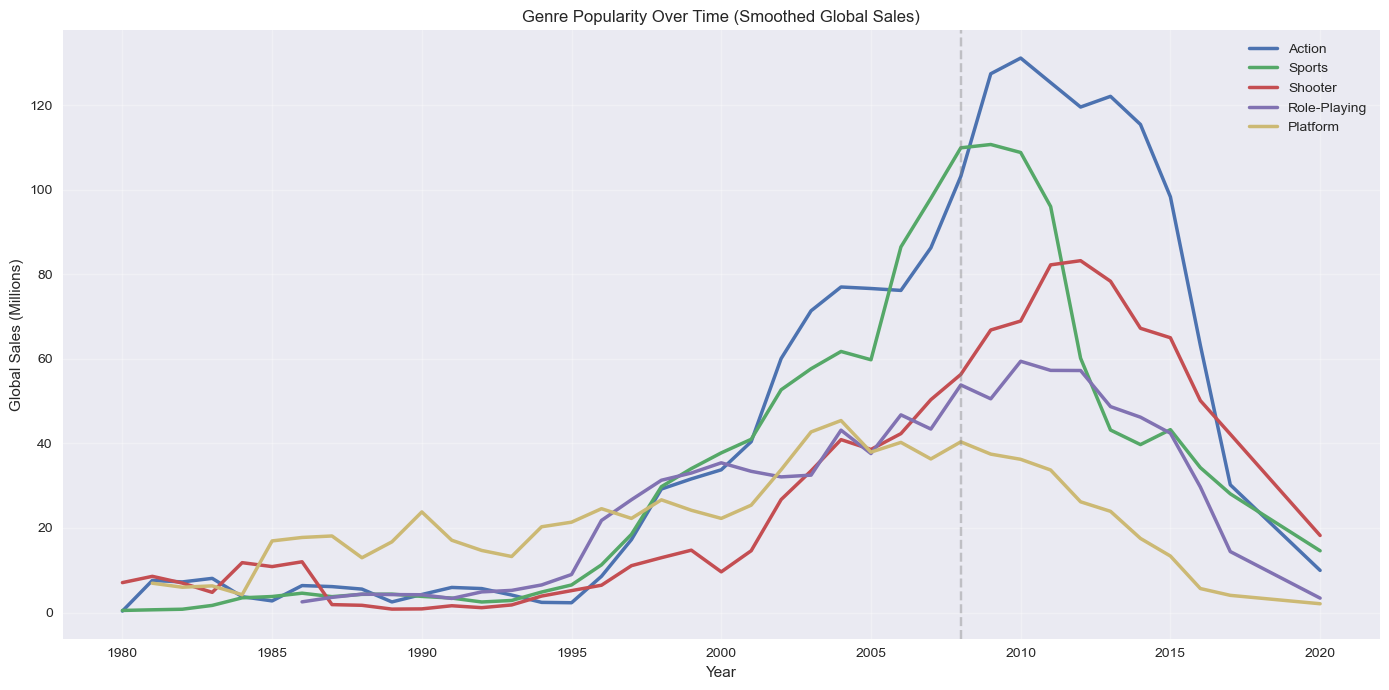

In [49]:
# Step 10 - Genre Popularity Over Time.

# Q. How has the popularity of each genre evolved over time, and which genres show rising or declining trends?

# Remove rows with missing Year
df_years = df.dropna(subset=["Year"])

# Total global sales per genre per year
genre_year_sales = (
    df_years.groupby(["Year", "Genre"])["Global_Sales"]
            .sum()
            .reset_index()
)
genre_year_sales.head()

# Pivot into a matrix: rows = Year, columns = Genre
genre_pivot = genre_year_sales.pivot(index="Year", columns="Genre", values="Global_Sales")

genre_pivot.head()

# Plot the top genres
import matplotlib.pyplot as plt

# --- 4. Smooth the data with a rolling average ---
genre_smooth = genre_pivot.rolling(window=3, min_periods=1).mean()

# --- 5. Select top 5 genres by total sales ---
top_genres = genre_pivot.sum().sort_values(ascending=False).head(5).index

# --- 6. Plot the smoothed trends ---
plt.style.use('seaborn-v0_8')  # cleaner visual style

plt.figure(figsize=(14,7))

for genre in top_genres:
    plt.plot(
        genre_smooth.index,
        genre_smooth[genre],
        label=genre,
        linewidth=2.5
    )

# Optional: highlight the 2008 peak year
plt.axvline(2008, color='grey', linestyle='--', alpha=0.4)

plt.title("Genre Popularity Over Time (Smoothed Global Sales)")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()







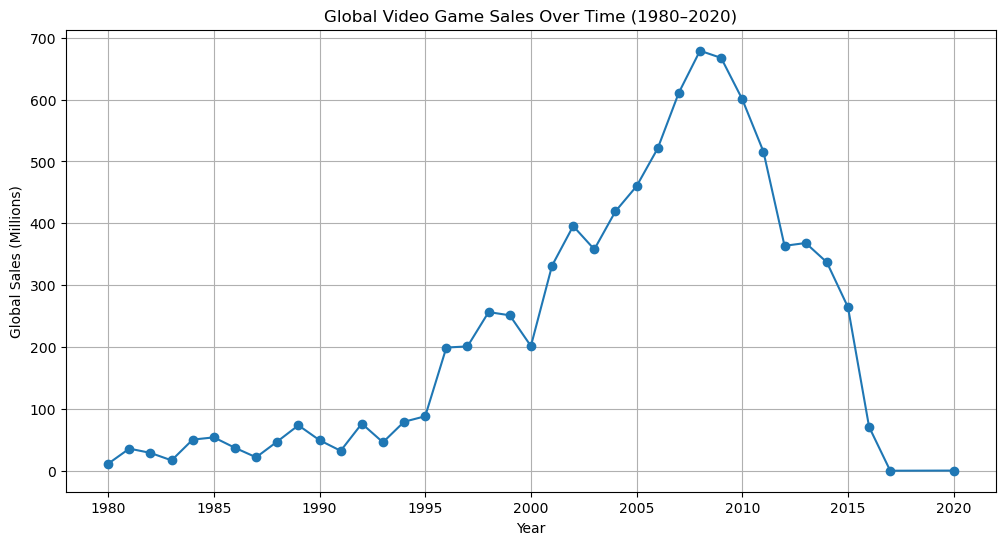

In [ ]:
# Step 9 - Continued. 

# Get the full sales‑per‑year series
sales_per_year

# Plot the Trend.
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(sales_per_year.index, sales_per_year.values, marker='o')
plt.title("Global Video Game Sales Over Time (1980–2020)")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.grid(True)
plt.show()

# Interpretation of Trend Results.
# 1980–1984 — Pre‑NES instability
#   Sales: 11 → 50 million

# 1985–1995 — Nintendo stabilizes the industry
#   Sales: 50 → 88 million

# 1996–2000 — The first explosion
#   Sales: 199 → 251 million

# 2001–2008 — The Golden Era of Gaming
#   Sales: 331 → 678 million

# 2009–2012 — The decline begins
#   Sales: 667 → 363 million

# 2013–2015 — The new normal
#   Sales: 368 → 264 million

# 2016–2020 — Dataset tail / missing modern platforms
#   Sales: 70 → 0.29 million


In [ ]:
# Step 9 - Sales Trends Over Time

# Q. How have total global video game sales changed from 1980 to 2020?

# Drop missing years
df_years = df.dropna(subset=["Year"])

# Total global sales per year
sales_per_year = (
    df_years.groupby("Year")["Global_Sales"]
            .sum()
            .sort_index()
)
sales_per_year.head()



Year
1980.0     11.38
1981.0     35.77
1982.0     28.86
1983.0     16.79
1984.0     50.36
1985.0     53.94
1986.0     37.07
1987.0     21.74
1988.0     47.22
1989.0     73.45
1990.0     49.39
1991.0     32.23
1992.0     76.16
1993.0     45.98
1994.0     79.17
1995.0     88.11
1996.0    199.15
1997.0    200.98
1998.0    256.47
1999.0    251.27
2000.0    201.56
2001.0    331.47
2002.0    395.52
2003.0    357.85
2004.0    419.31
2005.0    459.94
2006.0    521.04
2007.0    611.13
2008.0    678.90
2009.0    667.30
2010.0    600.45
2011.0    515.99
2012.0    363.54
2013.0    368.11
2014.0    337.05
2015.0    264.44
2016.0     70.93
2017.0      0.05
2020.0      0.29
Name: Global_Sales, dtype: float64

In [37]:
# Step 8 - Top Publishers by Global Sales.

# Q. Which publishers generate the highest total global sales, and how concentrated is the market among the top publishers? 

# Total global sales by publisher
publisher_sales = (
        df.groupby("Publisher")["Global_Sales"].sum()
        .sort_values(ascending=False) 
)
publisher_sales.head(10)

# Total global sales across all games
total_global_sales = df["Global_Sales"].sum()

# Market share for each publisher
publisher_share = (publisher_sales / total_global_sales) * 100

publisher_share.head(10)

Publisher
Nintendo                        20.027712
Electronic Arts                 12.446920
Activision                       8.154979
Sony Computer Entertainment      6.810202
Ubisoft                          5.321711
Take-Two Interactive             4.478927
THQ                              3.820103
Konami Digital Entertainment     3.179664
Sega                             3.060275
Namco Bandai Games               2.848402
Name: Global_Sales, dtype: float64

Step 7 — Building the Analysis Roadmap.

1️⃣ Top publishers by global sales

        groupby Publisher

        sum Global_Sales

        sort descending

        maybe compute % share

2️⃣ Sales trends over time

        drop NaN years

        groupby Year

        sum Global_Sales

        line plot

3️⃣ Genre popularity over time

        drop NaN years

        groupby Year + Genre

        sum Global_Sales

        pivot table (Year as index, Genre as columns)

        line plot per genre

4️⃣ Genre preferences by region

        groupby Genre

        sum NA_Sales, EU_Sales, JP_Sales, Other_Sales

        compare region totals

        maybe normalize

5️⃣ Publisher dominance by region

        groupby Publisher

        sum NA_Sales, EU_Sales, JP_Sales

        sort each region separately

6️⃣ Top 10 games contribution

        sort by Global_Sales

        take top 10

        sum top 10

        divide by total global sales

# Step 6 — Identify the Question Categories.

📈 Sales Performance

    Top publishers by global sales:
    Q.      Which publishers generate the highest total global sales, and how concentrated is the market among the top publishers?

📅 Time trends

    Sales trends over time:
    Q.     How have total global video game sales changed from 1980 to 2020, and what major peaks or declines appear?

    Genre popularity over time:
    Q.     How has the popularity of each genre evolved over time, and which genres show rising or declining trends?

🌍 Regional Differences

    Genre preferences by region:
    Q.     Do NA, EU, JP, and Other regions prefer different genres, and how do these preferences compare?

    Publisher dominance by region:
    Q.      Which publishers dominate each region, and are there region‑specific leaders?

🏆 Concentration

    How much do top 10 games contribute?:
    Q.      What percentage of total global sales is generated by the top 10 best‑selling games, and how concentrated is the market?

Step 5 — Anything Surprising? in regards to the Step 4 Dataset Findings.

The Popularity of each respective platform is directly tied to the volume/amount of games that were published at that respective platform and not based around which console was actually the most popular.

EA publishing the most titles isn't surprising, although Nintendo is synonymous and well known brand with a strong reputation, they tend to aim for quality over quantity which allows demand to grow for the products which results in strong individual sales as opposed to volume of sales from a range of games.



Step 4 — Describe & Explore the Dataset Findings:

🧩 Missing values

    Year (271 missing) → This is normal. Older games, arcade ports, or obscure releases often have no recorded year.

    Publisher (58 missing) → Also expected. Small indie releases or early titles often lack publisher metadata.

    Everything else is perfectly complete — a good sign of a clean dataset.


🎭 Genre distribution — very top‑heavy

Counts show:

    Action is overwhelmingly dominant (3316 games).

    Sports, Misc, Role‑Playing, Shooter follow.

This tells us the dataset is not evenly distributed, it reflects industry output, not balanced categories.
This matters later when we interpret sales trends: some genres simply have more games.

🎮 Platform distribution — DS and PS2 Dominate.

    This is one of the most interesting findings:

        DS (2163) and PS2 (2161) are the top platforms.

        Followed by PS3, Wii, Xbox 360, PSP, PS, PC, Xbox, GBA.

    This tells us the dataset is heavily skewed toward:

        2000–2015 era

        Console gaming dominance

        Nintendo + Sony ecosystems

    This will matter when we look at sales trends, DS and PS2 have huge libraries, so they naturally appear everywhere.

🏢 Publisher distribution — EA is King

    Top publishers:

        Electronic Arts (1351)

        Activision (975)

        Namco Bandai (932)

        Ubisoft (921)

        Konami (832)

        THQ (715)

        Nintendo (703)

        Sony Computer Entertainment (683)
    
    This is exactly what you’d expect from the 2000–2015 era:
    EA’s annual sports titles inflate their count massively.

📅 Year range — 1980 to 2020

This dataset spans 40 years, but the density is not even.
Most games cluster between 1995–2015, which we see later when we plot counts per year.

Step 4 Conclusion. — Dataset Description:

“This dataset contains 16k video games with global sales figures across regions, along with metadata like genre, platform, publisher, and release year. 
The data spans 1980–2020, though most games cluster in the 2000–2015 console era. Action games, DS/PS2 platforms, and publishers like EA dominate the dataset.


In [ ]:
# Step 3 — Missing Values + Categorical Exploration.

# 1. Missing values per column
df.isnull().sum()

# 2. Top categories
df["Genre"].value_counts().head(10)
df["Platform"].value_counts().head(10)
df["Publisher"].value_counts().head(10)

# 3. Year range (min/max)
df["Year"].min(), df["Year"].max()

(np.float64(1980.0), np.float64(2020.0))

In [19]:
# Step 2 — Shape, Columns, and Data Types

# 1. Shape: how many rows and columns?
df.shape

# 2. Column names as a clean list
df.columns.tolist()

# # 3. Data types of each column
df.dtypes

# # 4. Full info summary (non-null counts + memory footprint)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [ ]:
#  Step 1 – Set up Notebook and Load the CSV

# Initial Setup to explore Dataset - Video Game Sales.
import pandas as pd

# 1. Load the CSV Dataset, Kaggle Download.
df = pd.read_csv("data/vgsales.csv")

# 2. Clean column names (habit) - Removes Leading/Trailing Spaces aka "Year " vs. "Year"
df.columns = df.columns.str.strip()

# 3. Quick first look
df.head()



,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
